In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("SpotifyFeatures.csv")

In [5]:
print(df.columns.tolist())

['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


In [6]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [7]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "popularity"
]

X = df[features].copy()

print(X.shape)
X.head()

(232725, 11)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969,99373,0
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003,137373,1
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488,170267,3
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758,152427,0
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576,82625,4


In [8]:
print(X.isnull().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
popularity          0
dtype: int64


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(232725, 11)


In [10]:
popular_df = df[df["popularity"] >= 85].copy()
print("Розмір після фільтрації:", popular_df.shape)

Розмір після фільтрації: (417, 18)


In [11]:
inertia = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[1954726.384907165, 1661583.4531734642, 1523334.6430590297, 1407101.0826283072, 1331154.0642403688, 1261544.5150459837, 1198102.730995702, 1147315.97044313, 1086790.3778490545, 1045854.1485072209, 1009924.4983171097, 978180.5625618078, 954520.2971070446, 933247.0244678619]


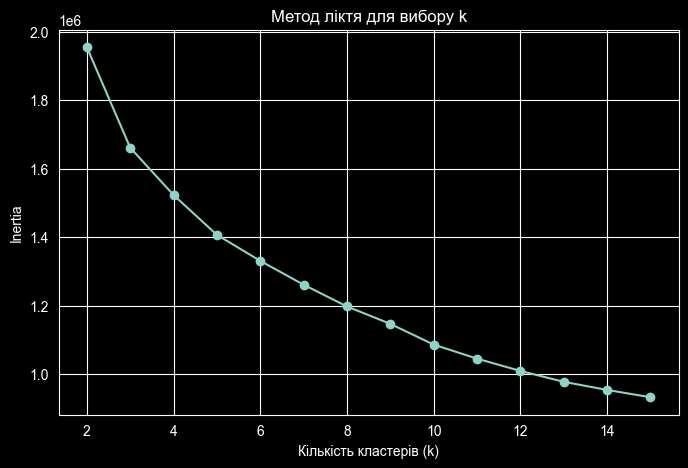

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Кількість кластерів (k)")
plt.ylabel("Inertia")
plt.title("Метод ліктя для вибору k")
plt.grid(True)
plt.show()

In [13]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print(df["cluster"].value_counts())

cluster
2    87225
1    60841
4    45108
0    29443
3    10108
Name: count, dtype: int64


In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print(X_pca.shape)

(232725, 2)


In [15]:
popular_df = df[df["popularity"] >= 85].copy()
print(popular_df.shape)

(417, 21)


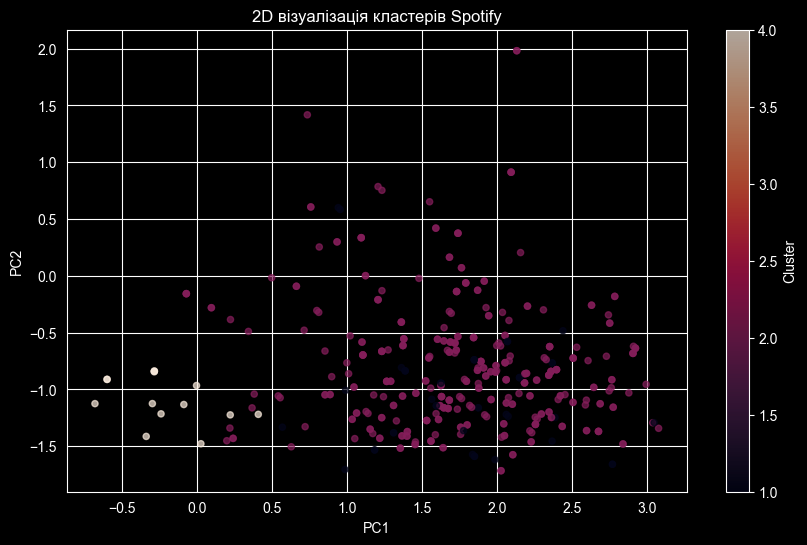

In [16]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    popular_df["PC1"],
    popular_df["PC2"],
    c=popular_df["cluster"],
    s=20,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D візуалізація кластерів Spotify")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [17]:
cluster_stats = df.groupby("cluster")[features].mean()
cluster_stats

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.286472,0.159595,-20.901594,0.046920,0.856315,0.680067,0.154202,0.148414,102.042368,263165.983358,26.823388
1,0.496335,0.770822,-6.003628,0.092733,0.103741,0.100486,0.250122,0.451372,145.110125,244797.228136,42.495439
2,0.696433,0.675507,-6.838729,0.106004,0.173918,0.049716,0.172171,0.603595,108.430522,224922.273614,49.511275
3,0.562452,0.662446,-12.025559,0.877295,0.793087,0.001236,0.730058,0.414211,97.952402,243765.745746,20.691531
4,0.530964,0.347222,-11.714480,0.065790,0.688625,0.089287,0.174762,0.381384,113.126768,221555.217168,36.986809


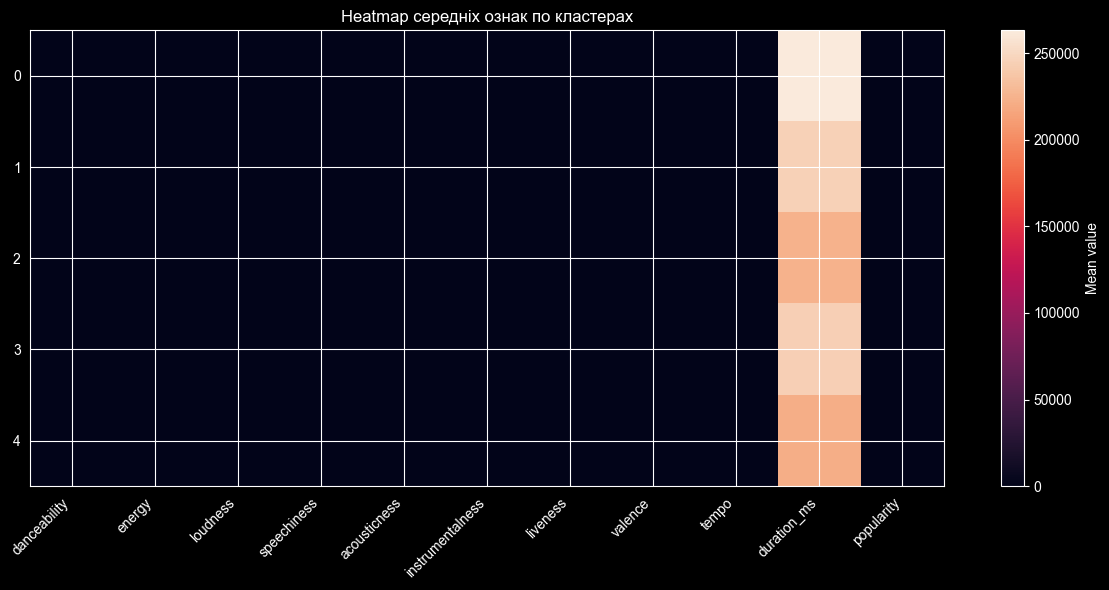

In [18]:
plt.figure(figsize=(12, 6))
plt.imshow(cluster_stats, aspect="auto")
plt.colorbar(label="Mean value")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(cluster_stats.index)), cluster_stats.index)
plt.title("Heatmap середніх ознак по кластерах")
plt.tight_layout()
plt.show()

In [19]:
for cluster_id in cluster_stats.index:
    print(f"\nКластер {cluster_id}")
    print(cluster_stats.loc[cluster_id].sort_values(ascending=False).head(3))


Кластер 0
duration_ms    263165.983358
tempo             102.042368
popularity         26.823388
Name: 0, dtype: float64

Кластер 1
duration_ms    244797.228136
tempo             145.110125
popularity         42.495439
Name: 1, dtype: float64

Кластер 2
duration_ms    224922.273614
tempo             108.430522
popularity         49.511275
Name: 2, dtype: float64

Кластер 3
duration_ms    243765.745746
tempo              97.952402
popularity         20.691531
Name: 3, dtype: float64

Кластер 4
duration_ms    221555.217168
tempo             113.126768
popularity         36.986809
Name: 4, dtype: float64
